#Capstone 3: Predicting iPSC Donor Differentiation Success#

I this project we will use iPSC scRNA-seq data from a dataset of 125 donors to predict endoderm differntiation efficiency. This dataset if from the publication

Cuomo, A.S.E., Seaton, D.D., McCarthy, D.J. *et al.*  
**Single-cell RNA-sequencing of differentiating iPS cells reveals dynamic genetic effects on gene expression.**  
*Nature Communications*, 11, 810 (2020).  
https://doi.org/10.1038/s41467-020-14457-z

The dataset can be dowloaded at: https://zenodo.org/record/3625024#.Xil-0y2cZ0s

The code used in this original publication can be found on Github: https://github.com/single-cell-genetics/singlecell_endodiff_paper/tree/main

##Loading Data

In this notebook we will build a predictive model using the scRNAseq counts from day0 cells (aka iPSCs prior to any differentiation) to predict the definitive endoderm (DE) score. This data can be found in the .h5ad file generated in the previous EDA notebook for this project and stored in the Google Drive foler Capstone3_iPSC_EDA.  There are two different DE scores that can be used as the target label, each with it's own dataset.

DEscore = Score derived from high expression of genes associated with endogenous definitive endoderm cells and low expression of genes associated with iPSCs, made using the `score_genes` function in the ScanPy library.

psuedorank = Score derived from the `psuedotime`, function in the ScanPy library which generates a progression from a randomly chosen day0 cell through the most differentiated cell in the dataset.

We'll start with mounting Google Drive, installing and importing the necessary libraries and loading the data files.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 54.8 gigabytes of available RAM

You are using a high-RAM runtime!


In [3]:
!pip install scanpy anndata seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 106.7 MB/s eta 0:00:00


In [4]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 23.2 MB/s eta 0:00:00


In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from xgboost.sklearn import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

We'll start the the DE score prediction and use this dataset to compare methods of dimensionality reduction while screenig various regression learners.  Once we develop a pipeline, we'll compare the donor ranking between the two scoring systems.

In [6]:
day0_score = sc.read_h5ad("/content/drive/MyDrive/Springboard/Capstone3_iPSC/Capstone3_iPSC_EDA/adata_DEscores_day0.h5ad")

In [7]:
day0_score.shape

(8841, 11231)

In [8]:
day0_score.obs.columns

Index(['cell_name', 'day', 'donor', 'DE_score_long', 'DE_score_short',
       'mean_DEscore_long', 'mean_DEscore_short', 'mean_pseudorank',
       'dpt_pseudotime', '2000_pseudotime'],
      dtype='object')

## Dimension Reduction

We will apply two methods of dimension reduction and compare the utility of the results.  

1) PCA, then use the PCs as features
2) Top 500 Highly Varible Genes

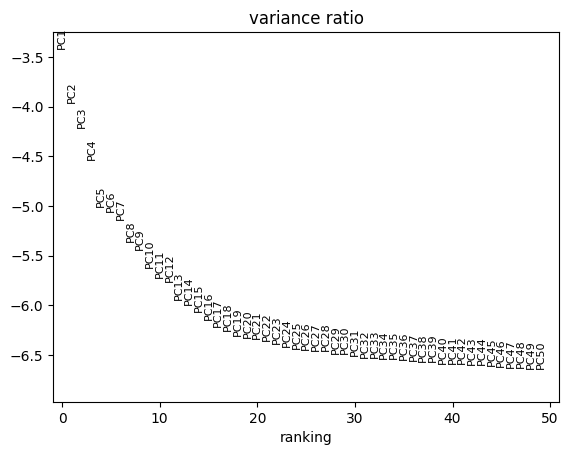

In [9]:
#Start with PCA method
sc.tl.pca(day0_score)
sc.pl.pca_variance_ratio(day0_score, n_pcs=50, log=True)

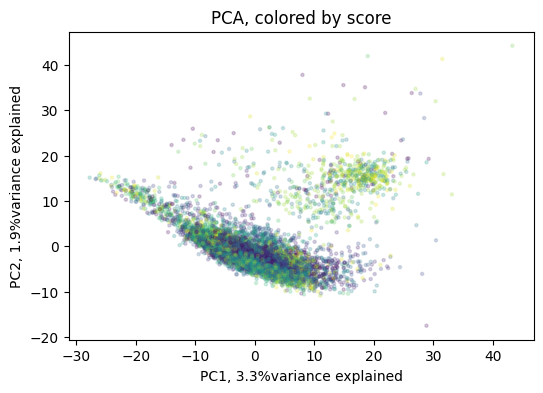

In [10]:
#Plot PCA, colored by DE score
perc_var = day0_score.uns['pca']['variance_ratio'] * 100
sc.tl.tsne(day0_score, use_rep='X_pca', random_state=147)
df = pd.DataFrame({'PC1': day0_score.obsm['X_pca'][:,0], 'PC2': day0_score.obsm['X_pca'][:,1], 'score': day0_score.obs['mean_DEscore_long'].values})

plt.figure(figsize=(6,4))
plt.scatter(df['PC1'], df['PC2'], c=pd.Categorical(df['score']).codes, s=5, alpha=0.2)
plt.xlabel(f'PC1, {perc_var[0]:.1f}%variance explained')
plt.ylabel(f'PC2, {perc_var[1]:.1f}%variance explained')
plt.title('PCA, colored by score')
plt.show()

It's not a great sign that the PCA isn't separating cells by score, so let's compare this to coloring by pseudorank.  To do this, we first need to make a column called `pseudorank` which will have the mean pseudotime for

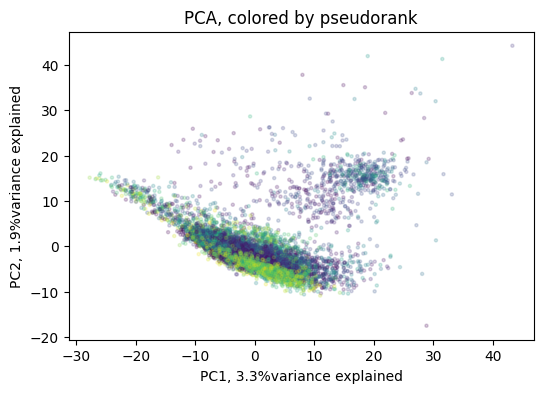

In [11]:
#Plot PCA, colored by pseudorank
perc_var = day0_score.uns['pca']['variance_ratio'] * 100
sc.tl.tsne(day0_score, use_rep='X_pca', random_state=147)
df = pd.DataFrame({'PC1': day0_score.obsm['X_pca'][:,0], 'PC2': day0_score.obsm['X_pca'][:,1], 'pseudorank': day0_score.obs['mean_pseudorank'].values})

plt.figure(figsize=(6,4))
plt.scatter(df['PC1'], df['PC2'], c=pd.Categorical(df['pseudorank']).codes, s=5, alpha=0.2)
plt.xlabel(f'PC1, {perc_var[0]:.1f}%variance explained')
plt.ylabel(f'PC2, {perc_var[1]:.1f}%variance explained')
plt.title('PCA, colored by pseudorank')
plt.show()

The PCA seems to organize cells by `pseudorank` a little better than by DE score.  We will still start with trying to predict the DE score first, since it is the more intuitive target, but will now include model screening for both targets before making a judgement on the best learners.

Now we will collect the PCs into a dataframe so we can use them as features for model building.

In [12]:
day0_pcs = pd.DataFrame(day0_score.obsm['X_pca'], index=day0_score.obs_names, columns=[f'PC{i+1}' for i in range(day0_score.obsm['X_pca'].shape[1])])
day0_pcs.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
21672_1#101,11.514328,-6.994431,0.571489,3.732512,2.671491,4.510236,3.443148,-1.090463,-4.614028,6.741590,...,-1.740905,2.351473,0.555447,1.570603,0.848649,-2.139615,1.754678,-1.118614,1.164804,1.094070
21672_1#102,4.982399,-5.017843,-4.158868,2.262005,2.489411,1.354592,-0.454386,1.546451,-2.111327,3.895255,...,-0.573356,-0.161609,-0.288230,-0.754360,-1.268227,1.291341,-1.113699,0.193002,-0.711179,0.742526
21672_1#105,9.985663,-6.111352,-1.624253,-0.408047,0.428268,-0.504835,-1.165807,3.668582,-3.520936,-0.683029,...,-3.932120,-1.762418,-0.451215,1.246646,1.123385,-0.896595,0.984266,-0.246984,2.631447,1.564411
21672_1#106,6.167212,-8.538262,-0.740149,3.888570,1.300684,1.824528,3.146211,0.608920,-5.119722,4.379023,...,-0.664580,1.226916,0.784656,-0.825795,-1.360577,1.355312,1.078723,-0.349598,0.834019,-1.690509
21672_1#107,5.443187,-5.269813,-0.636773,0.130608,0.600330,0.681045,5.394566,-6.177425,1.540475,0.863455,...,0.071698,-0.671896,3.336666,1.121986,2.050730,0.827908,0.438443,-0.885197,2.587804,-1.461933


In [13]:
day0_pcs.shape

(8841, 50)

In [14]:
#Now we need the metadata to get the labels
meta_df = day0_score.obs.copy()
meta_df.head()

,cell_name,day,donor,DE_score_long,DE_score_short,mean_DEscore_long,mean_DEscore_short,mean_pseudorank,dpt_pseudotime,2000_pseudotime
21672_1#101,21672_1#101,day0,zapk,-1.750065,-1.999580,2.296221,5.776403,0.719840,0.000000,0.000000
21672_1#102,21672_1#102,day0,wibj,-1.093724,-2.386349,1.908312,5.802939,0.763244,0.063370,0.013659
21672_1#105,21672_1#105,day0,pelm,-0.882502,-1.362223,1.768026,5.667831,0.690719,0.050821,0.009929
21672_1#106,21672_1#106,day0,zapk,-1.034337,-2.996357,2.296221,5.776403,0.719840,0.062232,0.014454
21672_1#107,21672_1#107,day0,zapk,-1.095111,-2.516784,2.296221,5.776403,0.719840,0.018551,0.014610


The target we will be predicting will be `mean_DEscore_long`, with long indicating that it was made from the longer list of genes described in the EDA notebook.

In [15]:
meta_df.shape

(8841, 10)

I used the Group Shuffle Split which splits the data between donors, ie the train and test set have different sets of donors.  This is in contrast to the standard train-test split which would split up the cells randomly regardless of donor, or a label based train-test split which would ensure that all donors are in both train and test groups.  I made this choice because future datasets that would be judged by this model would have cells for different donors.  The purpose of this model is to be able to judge new iPSC donors, not rejudge the ones it has already seen.

In [17]:
#Now do HVG method
sc.pp.highly_variable_genes(day0_score, n_top_genes=500, flavor='seurat', subset=False) #Define top 500 highly variable genes as True/False
day0_hvg = day0_score[:, day0_score.var.highly_variable].copy() #Subset data into the top most variable 500 genes

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_highly_variable_genes.py:383: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)


In [18]:
day0_hvg.shape

(8841, 500)

In [19]:
day0_hvgdf = pd.DataFrame(day0_hvg.X, index=day0_hvg.obs_names, columns=day0_hvg.var_names)
day0_hvgdf.head()

Unnamed: 0,ENSG00000004142_POLDIP2,ENSG00000004975_DVL2,ENSG00000005486_RHBDD2,ENSG00000006756_ARSD,ENSG00000007866_TEAD3,ENSG00000008869_HEATR5B,ENSG00000011028_MRC2,ENSG00000012983_MAP4K5,ENSG00000013375_PGM3,ENSG00000013561_RNF14,...,ENSG00000250588_IQCJ-SCHIP1,ENSG00000254184_TYW1B,ENSG00000254901_MEF2BNB,ENSG00000255562_UNC93B6,ENSG00000256379_TRAV8-5,ENSG00000257103_LSM14A,ENSG00000261052_SULT1A3,ENSG00000262261_GTF2H2D,ENSG00000262739_PRSS2,ENSG00000270872_SRGAP2D
21672_1#101,-0.328997,0.019007,-0.185744,-0.379425,-0.678354,-0.473778,0.117326,-0.946889,0.966179,2.483863,...,6.418861,1.587451,0.150872,-0.259889,-0.148764,2.681735,1.762553,0.767574,-0.250818,-0.318380
21672_1#102,0.130350,-0.426593,-0.952913,-0.388468,-0.678354,-0.400576,-0.601724,0.434278,-0.625611,-0.531236,...,1.669732,-0.474483,-0.128242,-0.259889,0.181405,-0.820518,1.740918,0.330708,-0.250818,-0.473806
21672_1#105,0.731487,0.781028,0.756299,-0.388468,1.116534,0.916271,-0.438959,0.614738,-0.138093,-0.986171,...,1.019590,-0.308987,0.446989,-0.259889,-0.640985,1.886772,-0.747688,-0.502005,-0.250818,0.376728
21672_1#106,-0.562212,0.487698,-0.181728,-0.388468,1.231957,-0.520882,-0.665291,-0.099867,0.028473,-0.699183,...,-0.238599,-0.093140,0.328730,-0.259889,0.464631,0.519706,0.766643,2.085741,-0.250818,-0.516029
21672_1#107,0.092531,0.271926,-0.215445,-0.388468,-0.678354,-0.068571,-0.614880,1.884792,-0.127004,0.005003,...,1.786935,0.231897,-0.917906,-0.259889,1.207260,0.719036,-0.611589,0.365872,-0.250818,0.496183


We now have two data sets based on different dimension reduction methods ready for the train/test split.  I'll keep the split in the same section as the model screening to prevent confusion.

## Model Building: Screening Models

I will use the Group Shuffle Split which splits the data between donors, ie the train and test set have different sets of donors.  This is in contrast to the standard train-test split which would split up the cells randomly regardless of donor, or a label based train-test split which would ensure that all donors are in both train and test groups.  I made this choice because future datasets that would be judged by this model would have cells for different donors.  The purpose of this model is to be able to judge new iPSC donors, not rejudge the ones it has already seen.

###Predicting DE Score

####PCA Method

 Given that our features already come in order of importance, additional dimension reduction with the SVM is unnecessary.  We will move straight into regression models.

 In the first stage, I'll test the following regression models with default hyperparameters to determine which model gives the best starting point.  The models will be evaluated using the Mean Absolute Error (MAE) and R-squared metrics.

1. Linear Regression
2. Support Vector Machine (SVM)
3. Random Forest Regressor
4. Gradient Boost Regressor
5. XGBoost Regressor
6. LiteGM Regressor
7. CatBoost Regressor

In [212]:
# Our X and y are already in separate varibles, so let's rename them as such for clarity, then we can do a train, test split.
X = day0_pcs.copy()
y = meta_df['mean_DEscore_long'].copy()
groups = meta_df['donor'].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=147)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_pcs, X_test_pcs = X.iloc[train_idx], X.iloc[test_idx]
y_train_pcs, y_test_pcs = y.iloc[train_idx], y.iloc[test_idx]

In [213]:
#Run default linear regression on dataset
LR = LinearRegression()
LR.fit(X_train_pcs, y_train_pcs)
LR.score(X_train_pcs, y_train_pcs)

0.3428034511005722

In [214]:
#Determine MAE with test data
y_pred_LR = np.array(LR.predict(X_test_pcs))
mae_LR = mean_absolute_error(y_test_pcs, y_pred_LR)
mape_LR = mean_absolute_percentage_error(y_test_pcs, y_pred_LR)
print(f'Linear Regression MAE: {mae_LR}')

Linear Regression MAE: 0.4535351526263435


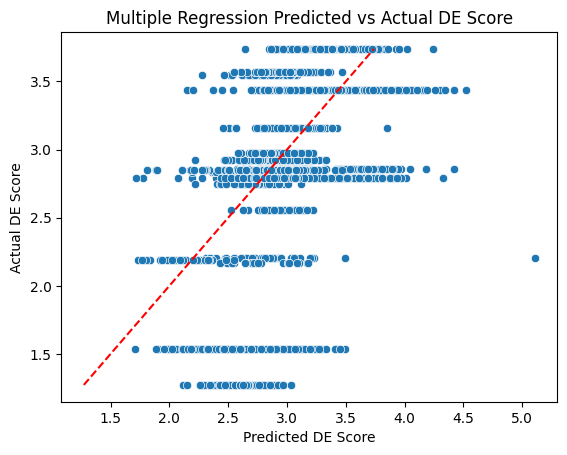

In [215]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LR, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Multiple Regression Predicted vs Actual DE Score')
plt.show()

In [216]:
#Run default SVM regression on dataset
SR = LinearSVR()
SR.fit(X_train_pcs, y_train_pcs)
SR.score(X_train_pcs, y_train_pcs)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.2078666667285054

In [217]:
#Determine MAE with test data
y_pred_SR = np.array(SR.predict(X_test_pcs))
mae_SR = mean_absolute_error(y_test_pcs, y_pred_SR)
mape_SR = mean_absolute_percentage_error(y_test_pcs, y_pred_SR)
print(f'SVM Regression MAE: {mae_SR}')

SVM Regression MAE: 0.46756976706834474


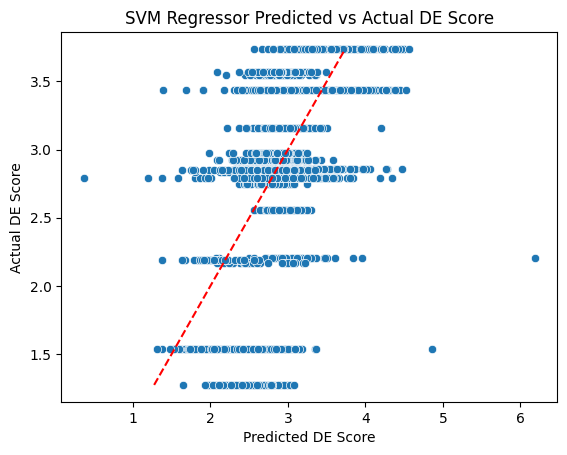

In [218]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_SR, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('SVM Regressor Predicted vs Actual DE Score')
plt.show()

In [219]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_pcs, y_train_pcs)
RF.score(X_train_pcs, y_train_pcs)

0.9303413003635754

In [220]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_pcs))
mae_RF = mean_absolute_error(y_test_pcs, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_pcs, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.4559826897982731


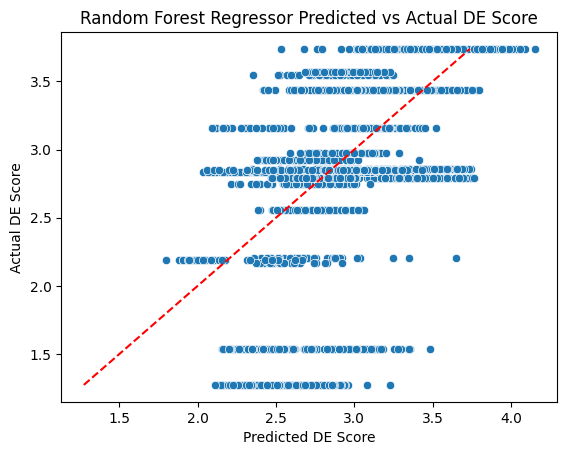

In [221]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Random Forest Regressor Predicted vs Actual DE Score')
plt.show()

In [222]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_pcs, y_train_pcs)
GB.score(X_train_pcs, y_train_pcs)

0.5606923643571364

In [223]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_pcs))
mae_GB = mean_absolute_error(y_test_pcs, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_pcs, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.4501923803205108


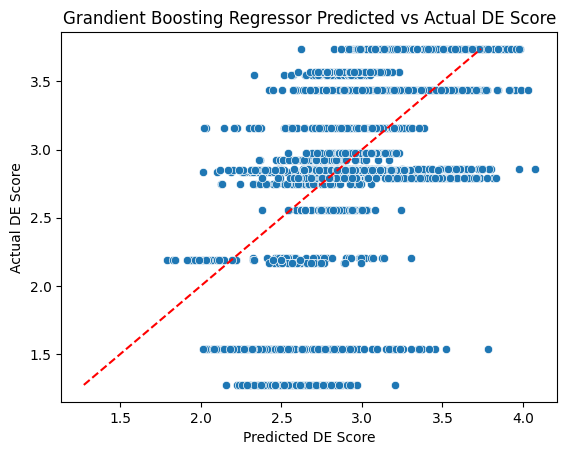

In [224]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Grandient Boosting Regressor Predicted vs Actual DE Score')
plt.show()

In [225]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_pcs, y_train_pcs)
XG.score(X_train_pcs, y_train_pcs)

0.9820168261122582

In [226]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_pcs))
mae_XG = mean_absolute_error(y_test_pcs, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_pcs, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.4686441570765865


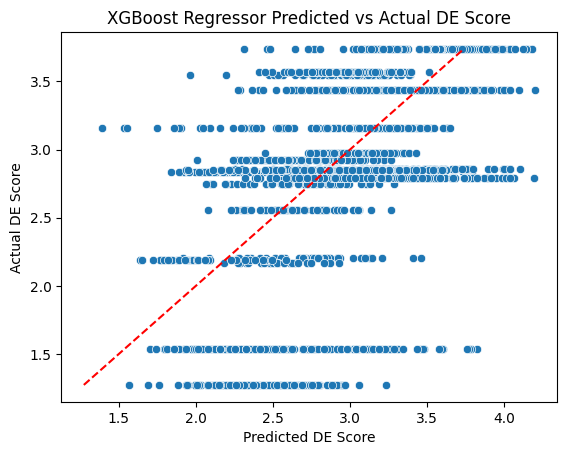

In [227]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('XGBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [228]:
#Run default LiteGBM regression on dataset
LG = LGBMRegressor()
LG.fit(X_train_pcs, y_train_pcs)
LG.score(X_train_pcs, y_train_pcs)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 6551, number of used features: 50
[LightGBM] [Info] Start training from score 2.761725


0.8174416211039682

In [229]:
#Determine MAE with test data
y_pred_LG = np.array(XG.predict(X_test_pcs))
mae_LG = mean_absolute_error(y_test_pcs, y_pred_LG)
mape_LG = mean_absolute_percentage_error(y_test_pcs, y_pred_LG)
print(f'LiteGBM Regressor MAE: {mae_LG}')

LiteGBM Regressor MAE: 0.4686441570765865


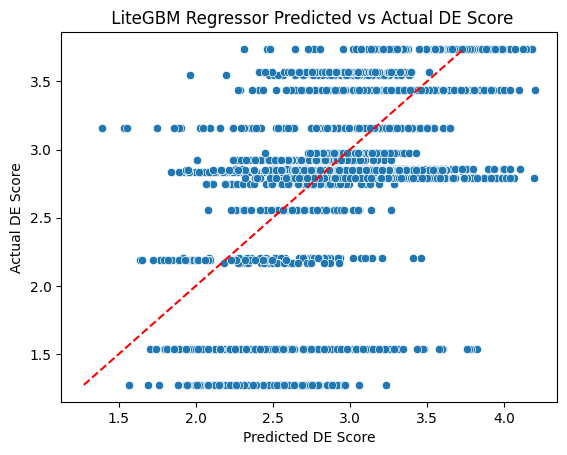

In [230]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LG, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title(' LiteGBM Regressor Predicted vs Actual DE Score')
plt.show()

In [231]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor()
CB.fit(X_train_pcs, y_train_pcs)
CB.score(X_train_pcs, y_train_pcs)

Learning rate set to 0.055101
0:	learn: 0.5973660	total: 7.06ms	remaining: 7.06s
1:	learn: 0.5902510	total: 11.6ms	remaining: 5.81s
2:	learn: 0.5826449	total: 17.2ms	remaining: 5.7s
3:	learn: 0.5763698	total: 21.7ms	remaining: 5.42s
4:	learn: 0.5701625	total: 26.2ms	remaining: 5.22s
5:	learn: 0.5637911	total: 30.5ms	remaining: 5.06s
6:	learn: 0.5577127	total: 35ms	remaining: 4.96s
7:	learn: 0.5524611	total: 39.3ms	remaining: 4.87s
8:	learn: 0.5474273	total: 43.6ms	remaining: 4.8s
9:	learn: 0.5422339	total: 48.1ms	remaining: 4.76s
10:	learn: 0.5375291	total: 52.4ms	remaining: 4.71s
11:	learn: 0.5340964	total: 56.6ms	remaining: 4.66s
12:	learn: 0.5303363	total: 60.9ms	remaining: 4.62s
13:	learn: 0.5267091	total: 65.3ms	remaining: 4.6s
14:	learn: 0.5232138	total: 69.5ms	remaining: 4.56s
15:	learn: 0.5197372	total: 73.8ms	remaining: 4.54s
16:	learn: 0.5163148	total: 78.2ms	remaining: 4.52s
17:	learn: 0.5130670	total: 82.5ms	remaining: 4.5s
18:	learn: 0.5101421	total: 86.9ms	remaining: 4.49

np.float64(0.9054080936084551)

In [232]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_pcs))
mae_CB = mean_absolute_error(y_test_pcs, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_pcs, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.4407672290609918


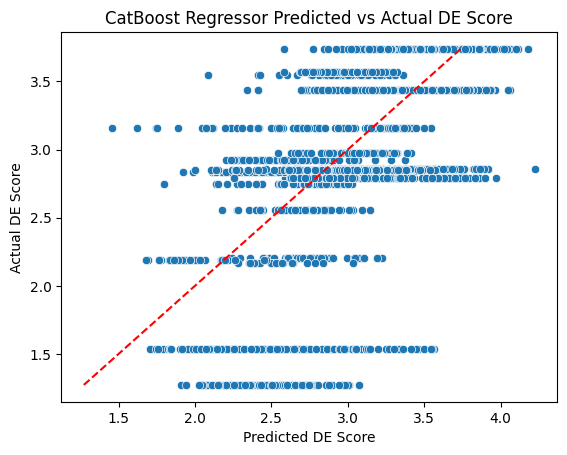

In [233]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('CatBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [234]:
MAE_dict = {'Multiple Linear Regression': mae_LR, 'SVM Regressor': mae_SR, 'Random Forest Regressor': mae_RF,
            'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'LiteGBM Regressor': mae_LG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Multiple Linear Regression': mape_LR, 'SVM Regressor': mape_SR, 'Random Forest Regressor': mape_RF,
            'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'LiteGBM Regressor': mape_LG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Multiple Linear Regression': LR.score(X_train_pcs, y_train_pcs), 'SVM Regressor': SR.score(X_train_pcs, y_train_pcs),
                 'Random Forest Regressor': RF.score(X_train_pcs, y_train_pcs), 'Gradient Boost Regressor': GB.score(X_train_pcs, y_train_pcs),
                 'XGBoost Regressor': XG.score(X_train_pcs, y_train_pcs), 'LiteGBM Regressor': LG.score(X_train_pcs, y_train_pcs), 'CatBoost Regressor': CB.score(X_train_pcs, y_train_pcs)}
summary_DE_PCA = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_DE_PCA

,MAE,MAPE,R²
Multiple Linear Regression,0.453535,0.222941,0.342803
SVM Regressor,0.467570,0.218851,0.207867
Random Forest Regressor,0.455983,0.222411,0.930341
Gradient Boost Regressor,0.450192,0.220855,0.560692
XGBoost Regressor,0.468644,0.222058,0.982017
LiteGBM Regressor,0.468644,0.222058,0.817442
CatBoost Regressor,0.440767,0.212509,0.905408


Summary of model screening following PCA dimension rediction: Models vary primarily in R2 values (ranging from 0.27 to 0.98) yet the MAE values are all pretty consistent around 0.45 (range from 0.477 to 0.44).  Furthermore, the scatterplots comparing predicted to actual DE scores show us that all models generate similar predictions and predominatly fail to find a pattern in the data.  The Random Forest and CatBoost regressors to the best, but not good enough to pursue further.  

The next step is to repeat this screening with the HVG dimension reduction data.

####HVG Method

 Similar to above, I'll test the following regression models with default hyperparameters to determine which model gives the best starting point.  The models will be evaluated using the Mean Absolute Error (MAE) and R-squared metrics.

1. Linear Regression
2. Support Vector Machine (SVM)
3. Random Forest Regressor
4. Gradient Boost Regressor
5. XGBoost Regressor
6. LiteGM Regressor
7. CatBoost Regressor

In [235]:
X = day0_hvgdf.copy()
y = meta_df['mean_DEscore_long'].copy()
groups = meta_df['donor'].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=147)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_hvg, X_test_hvg = X.iloc[train_idx], X.iloc[test_idx]
y_train_hvg, y_test_hvg = y.iloc[train_idx], y.iloc[test_idx]

In [236]:
#Run default linear regression on dataset
LR = LinearRegression()
LR.fit(X_train_hvg, y_train_hvg)
LR.score(X_train_hvg, y_train_hvg)

0.3428401173222927

In [237]:
#Determine MAE with test data
y_pred_LR = np.array(LR.predict(X_test_hvg))
mae_LR = mean_absolute_error(y_test_hvg, y_pred_LR)
mape_LR = mean_absolute_percentage_error(y_test_hvg, y_pred_LR)
print(f'Linear Regression MAE: {mae_LR}')

Linear Regression MAE: 0.4885947653144312


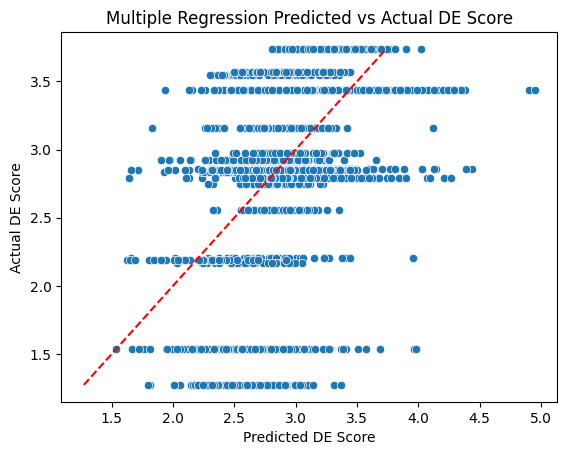

In [238]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LR, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Multiple Regression Predicted vs Actual DE Score')
plt.show()

In [239]:
#Run default SVM regression on dataset
SR = LinearSVR()
SR.fit(X_train_hvg, y_train_hvg)
SR.score(X_train_hvg, y_train_hvg)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.2007199627725046

In [240]:
#Determine MAE with test data
y_pred_SR = np.array(SR.predict(X_test_hvg))
mae_SR = mean_absolute_error(y_test_hvg, y_pred_SR)
mape_SR = mean_absolute_percentage_error(y_test_hvg, y_pred_SR)
print(f'SVM Regression MAE: {mae_SR}')

SVM Regression MAE: 0.5200550714710438


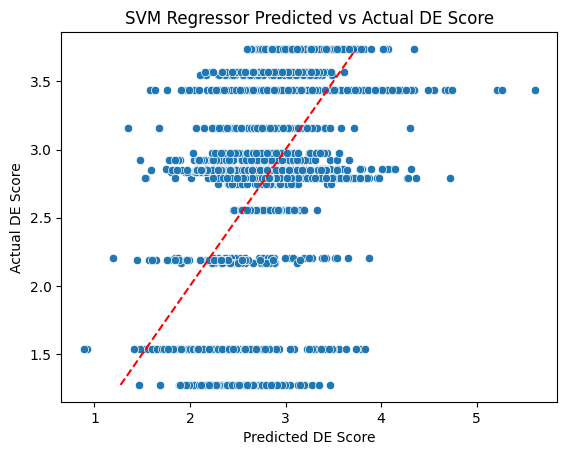

In [241]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_SR, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('SVM Regressor Predicted vs Actual DE Score')
plt.show()

In [242]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_hvg, y_train_hvg)
RF.score(X_train_hvg, y_train_hvg)

0.8906293974612884

In [243]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_hvg))
mae_RF = mean_absolute_error(y_test_hvg, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_hvg, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.4734195607231027


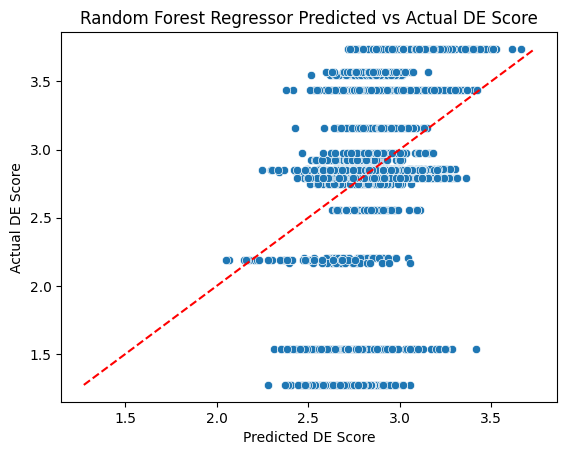

In [244]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Random Forest Regressor Predicted vs Actual DE Score')
plt.show()

In [245]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_hvg, y_train_hvg)
GB.score(X_train_hvg, y_train_hvg)

0.4690622501691596

In [246]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_hvg))
mae_GB = mean_absolute_error(y_test_hvg, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_hvg, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.4663220982517263


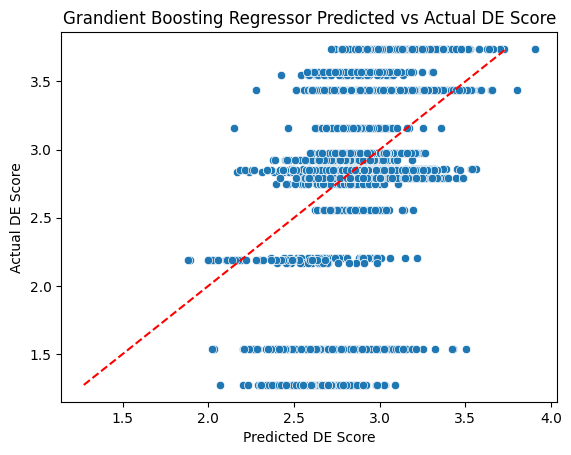

In [247]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('Grandient Boosting Regressor Predicted vs Actual DE Score')
plt.show()

In [248]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_hvg, y_train_hvg)
XG.score(X_train_hvg, y_train_hvg)

0.9958167612956832

In [249]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_hvg))
mae_XG = mean_absolute_error(y_test_hvg, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_hvg, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.5025002618535821


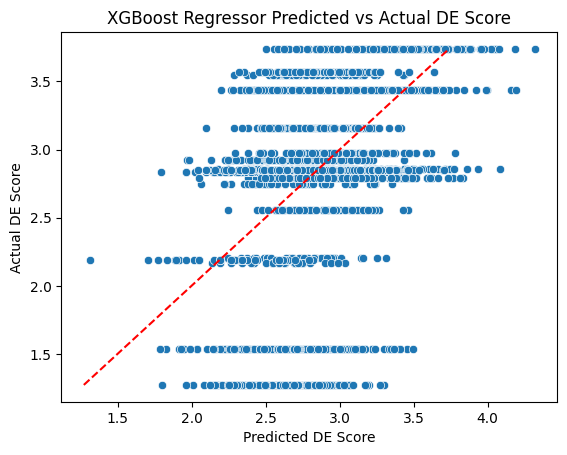

In [250]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('XGBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [251]:
#Run default LiteGBM regression on dataset
LG = LGBMRegressor()
LG.fit(X_train_hvg, y_train_hvg)
LG.score(X_train_hvg, y_train_hvg)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018828 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 126156
[LightGBM] [Info] Number of data points in the train set: 6551, number of used features: 500
[LightGBM] [Info] Start training from score 2.761725


0.8272705643351655

In [252]:
#Determine MAE with test data
y_pred_LG = np.array(XG.predict(X_test_hvg))
mae_LG = mean_absolute_error(y_test_hvg, y_pred_LG)
mape_LG = mean_absolute_percentage_error(y_test_hvg, y_pred_LG)
print(f'LiteGBM Regressor MAE: {mae_LG}')

LiteGBM Regressor MAE: 0.5025002618535821


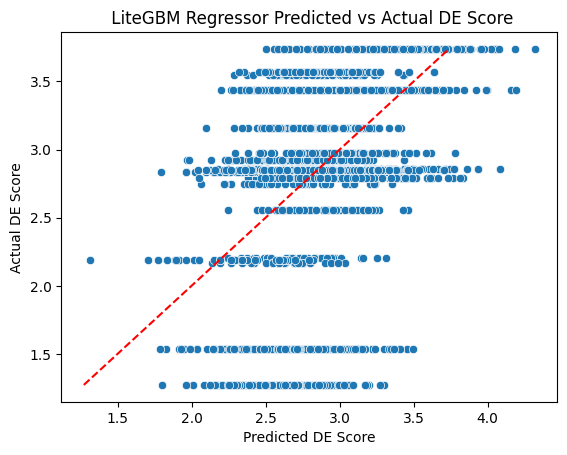

In [253]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LG, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title(' LiteGBM Regressor Predicted vs Actual DE Score')
plt.show()

In [254]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor()
CB.fit(X_train_hvg, y_train_hvg)
CB.score(X_train_hvg, y_train_hvg)

Learning rate set to 0.055101
0:	learn: 0.6027067	total: 52.8ms	remaining: 52.8s
1:	learn: 0.6001751	total: 92.3ms	remaining: 46s
2:	learn: 0.5970226	total: 137ms	remaining: 45.6s
3:	learn: 0.5945601	total: 176ms	remaining: 43.9s
4:	learn: 0.5921038	total: 214ms	remaining: 42.6s
5:	learn: 0.5897099	total: 250ms	remaining: 41.5s
6:	learn: 0.5873171	total: 286ms	remaining: 40.6s
7:	learn: 0.5851925	total: 323ms	remaining: 40.1s
8:	learn: 0.5828251	total: 361ms	remaining: 39.8s
9:	learn: 0.5804264	total: 401ms	remaining: 39.7s
10:	learn: 0.5783044	total: 438ms	remaining: 39.4s
11:	learn: 0.5763738	total: 475ms	remaining: 39.1s
12:	learn: 0.5740713	total: 511ms	remaining: 38.8s
13:	learn: 0.5720562	total: 547ms	remaining: 38.5s
14:	learn: 0.5706075	total: 584ms	remaining: 38.4s
15:	learn: 0.5686890	total: 624ms	remaining: 38.4s
16:	learn: 0.5669158	total: 663ms	remaining: 38.4s
17:	learn: 0.5653797	total: 701ms	remaining: 38.3s
18:	learn: 0.5637499	total: 739ms	remaining: 38.1s
19:	learn: 

np.float64(0.9204065880215961)

In [255]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_hvg))
mae_CB = mean_absolute_error(y_test_hvg, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_hvg, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.4594164861315019


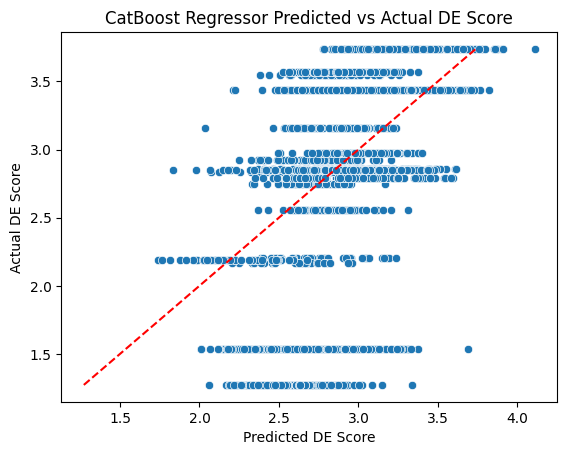

In [256]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted DE Score')
plt.ylabel('Actual DE Score')
plt.title('CatBoost Regressor Predicted vs Actual DE Score')
plt.show()

In [257]:
MAE_dict = {'Multiple Linear Regression': mae_LR, 'SVM Regressor': mae_SR, 'Random Forest Regressor': mae_RF,
            'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'LiteGBM Regressor': mae_LG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Multiple Linear Regression': mape_LR, 'SVM Regressor': mape_SR, 'Random Forest Regressor': mape_RF,
            'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'LiteGBM Regressor': mape_LG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Multiple Linear Regression': LR.score(X_train_hvg, y_train_hvg), 'SVM Regressor': SR.score(X_train_hvg, y_train_hvg),
                 'Random Forest Regressor': RF.score(X_train_hvg, y_train_hvg), 'Gradient Boost Regressor': GB.score(X_train_hvg, y_train_hvg),
                 'XGBoost Regressor': XG.score(X_train_hvg, y_train_hvg), 'LiteGBM Regressor': LG.score(X_train_hvg, y_train_hvg), 'CatBoost Regressor': CB.score(X_train_hvg, y_train_hvg)}
summary_DE_HVG = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_DE_HVG

,MAE,MAPE,R²
Multiple Linear Regression,0.488595,0.236452,0.342840
SVM Regressor,0.520055,0.237419,0.200720
Random Forest Regressor,0.473420,0.236012,0.890629
Gradient Boost Regressor,0.466322,0.232873,0.469062
XGBoost Regressor,0.502500,0.243171,0.995817
LiteGBM Regressor,0.502500,0.243171,0.827271
CatBoost Regressor,0.459416,0.228644,0.920407


Summary of model screening following HVG dimension rediction: The results for the HVG approach are the same as the PCA approach - all models fail to find a pattern in the data capable of predicting the DE score on a single cell level.

Since learners failed to predict the DE score, I'll now repeat the above screening with pseudorank as the target.

###Predicting Pseuodrank

####PCA Method

We'll repeat the test of the same seven learners with pseudrank as the target.

1. Linear Regression
2. Support Vector Machine (SVM)
3. Random Forest Regressor
4. Gradient Boost Regressor
5. XGBoost Regressor
6. LiteGM Regressor
7. CatBoost Regressor

In [159]:
# repeat the train/test split with the new y
X = day0_pcs.copy()
y = meta_df['mean_pseudorank'].copy()
groups = meta_df['donor'].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=147)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_pcs, X_test_pcs = X.iloc[train_idx], X.iloc[test_idx]
y_train_pcs, y_test_pcs = y.iloc[train_idx], y.iloc[test_idx]

In [160]:
#Run default linear regression on dataset
LR = LinearRegression()
LR.fit(X_train_pcs, y_train_pcs)
LR.score(X_train_pcs, y_train_pcs)

0.3853716254234314

In [161]:
#Determine MAE with test data
y_pred_LR = np.array(LR.predict(X_test_pcs))
mae_LR = mean_absolute_error(y_test_pcs, y_pred_LR)
mape_LR = mean_absolute_percentage_error(y_test_pcs, y_pred_LR)
print(f'Linear Regression MAE: {mae_LR}')

Linear Regression MAE: 0.022616591304540634


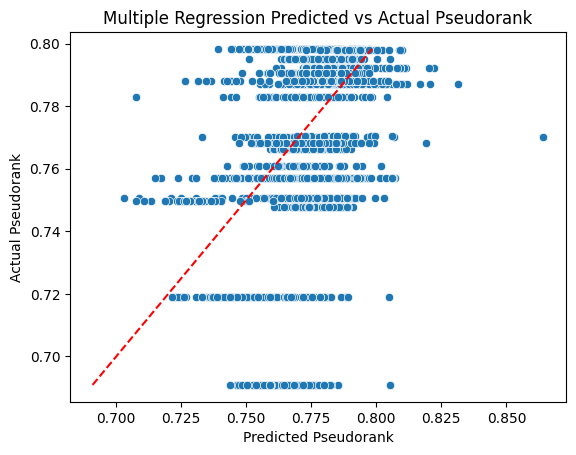

In [162]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LR, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Multiple Regression Predicted vs Actual Pseudorank')
plt.show()

In [163]:
#Run default SVM regression on dataset
SR = LinearSVR()
SR.fit(X_train_pcs, y_train_pcs)
SR.score(X_train_pcs, y_train_pcs)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


-0.7158535471076601

In [164]:
#Determine MAE with test data
y_pred_SR = np.array(SR.predict(X_test_pcs))
mae_SR = mean_absolute_error(y_test_pcs, y_pred_SR)
mape_SR = mean_absolute_percentage_error(y_test_pcs, y_pred_SR)
print(f'SVM Regression MAE: {mae_SR}')

SVM Regression MAE: 0.030324078131687544


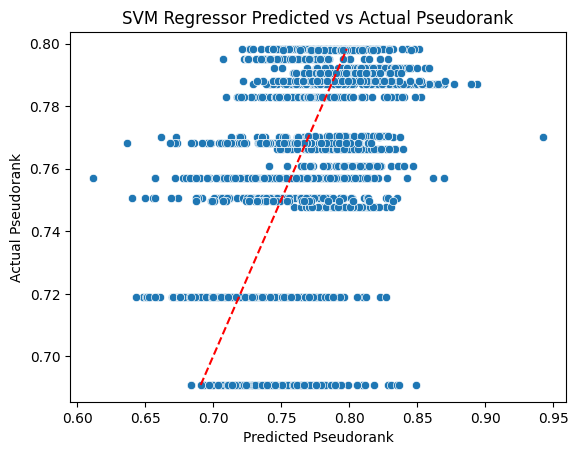

In [165]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_SR, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('SVM Regressor Predicted vs Actual Pseudorank')
plt.show()

In [166]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_pcs, y_train_pcs)
RF.score(X_train_pcs, y_train_pcs)

0.9298713034143202

In [167]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_pcs))
mae_RF = mean_absolute_error(y_test_pcs, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_pcs, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.021086846861256267


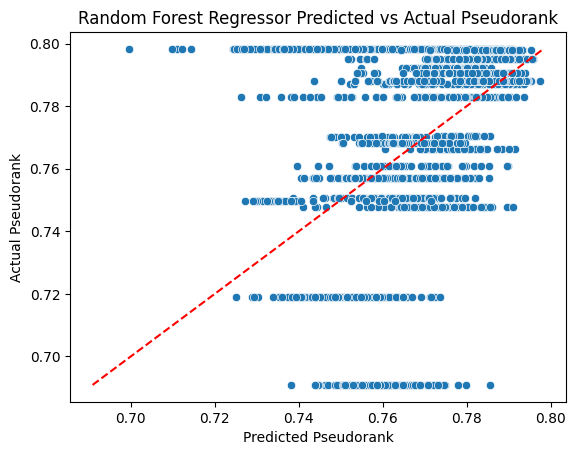

In [168]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Random Forest Regressor Predicted vs Actual Pseudorank')
plt.show()

In [169]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_pcs, y_train_pcs)
GB.score(X_train_pcs, y_train_pcs)

0.5983881452020481

In [170]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_pcs))
mae_GB = mean_absolute_error(y_test_pcs, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_pcs, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.02236357923269103


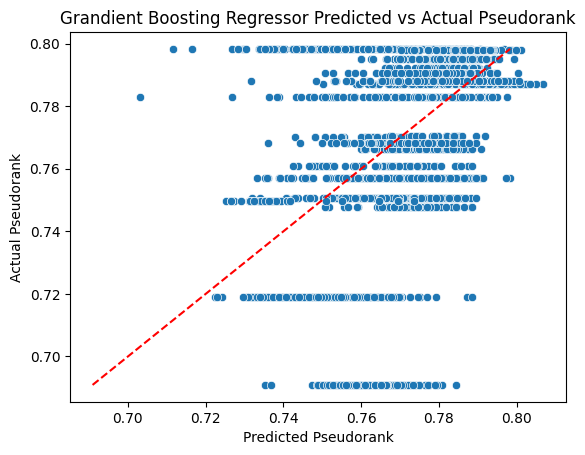

In [171]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Grandient Boosting Regressor Predicted vs Actual Pseudorank')
plt.show()

In [172]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_pcs, y_train_pcs)
XG.score(X_train_pcs, y_train_pcs)

0.9835835099220276

In [173]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_pcs))
mae_XG = mean_absolute_error(y_test_pcs, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_pcs, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.022450698539614677


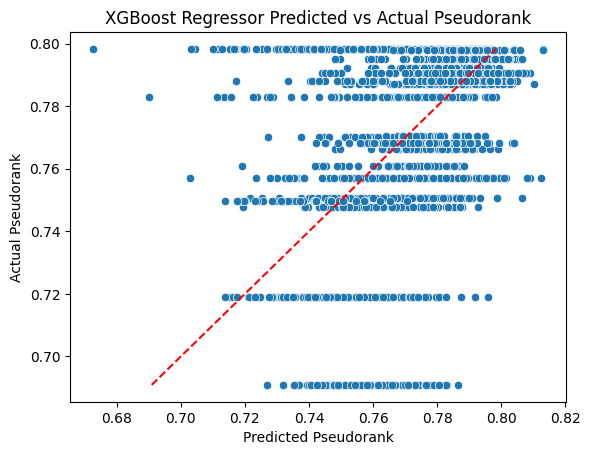

In [174]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('XGBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [175]:
#Run default LiteGBM regression on dataset
LG = LGBMRegressor()
LG.fit(X_train_pcs, y_train_pcs)
LG.score(X_train_pcs, y_train_pcs)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001225 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 6551, number of used features: 50
[LightGBM] [Info] Start training from score 0.767689


0.857551620736666

In [176]:
#Determine MAE with test data
y_pred_LG = np.array(XG.predict(X_test_pcs))
mae_LG = mean_absolute_error(y_test_pcs, y_pred_LG)
mape_LG = mean_absolute_percentage_error(y_test_pcs, y_pred_LG)
print(f'LiteGBM Regressor MAE: {mae_LG}')

LiteGBM Regressor MAE: 0.022450698539614677


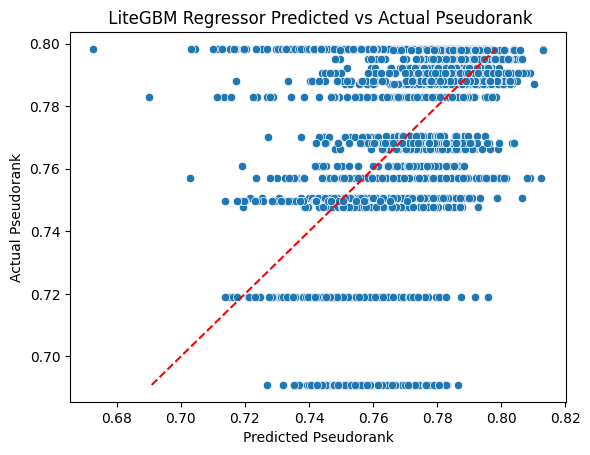

In [177]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LG, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title(' LiteGBM Regressor Predicted vs Actual Pseudorank')
plt.show()

In [178]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor()
CB.fit(X_train_pcs, y_train_pcs)
CB.score(X_train_pcs, y_train_pcs)

Learning rate set to 0.055101
0:	learn: 0.0271250	total: 6.67ms	remaining: 6.66s
1:	learn: 0.0267673	total: 11.5ms	remaining: 5.75s
2:	learn: 0.0264512	total: 16.4ms	remaining: 5.45s
3:	learn: 0.0261476	total: 21.2ms	remaining: 5.27s
4:	learn: 0.0258578	total: 26.4ms	remaining: 5.25s
5:	learn: 0.0255912	total: 31.4ms	remaining: 5.19s
6:	learn: 0.0253047	total: 36.3ms	remaining: 5.14s
7:	learn: 0.0250486	total: 41.4ms	remaining: 5.14s
8:	learn: 0.0248592	total: 46.4ms	remaining: 5.11s
9:	learn: 0.0246618	total: 51.2ms	remaining: 5.07s
10:	learn: 0.0244742	total: 56.2ms	remaining: 5.06s
11:	learn: 0.0243230	total: 61.3ms	remaining: 5.05s
12:	learn: 0.0241671	total: 66.3ms	remaining: 5.03s
13:	learn: 0.0240055	total: 70.9ms	remaining: 5s
14:	learn: 0.0238721	total: 75.7ms	remaining: 4.97s
15:	learn: 0.0237237	total: 80.8ms	remaining: 4.97s
16:	learn: 0.0235829	total: 86.7ms	remaining: 5.01s
17:	learn: 0.0234365	total: 91.6ms	remaining: 5s
18:	learn: 0.0232804	total: 96.4ms	remaining: 4.98

np.float64(0.9169283572876296)

In [179]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_pcs))
mae_CB = mean_absolute_error(y_test_pcs, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_pcs, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.021973480666114015


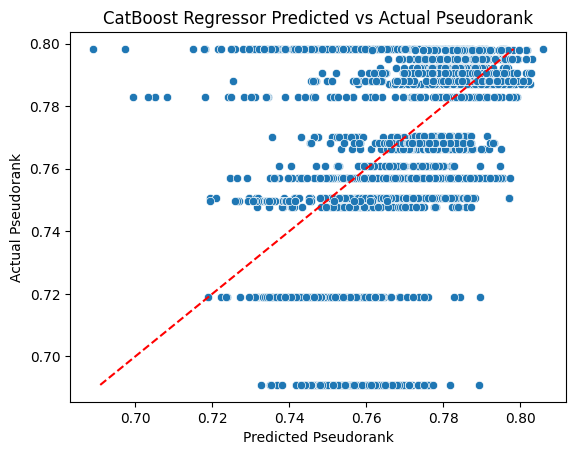

In [180]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_pcs)

# Add a line for perfect correlation.
plt.plot([y_test_pcs.min(), y_test_pcs.max()],
         [y_test_pcs.min(), y_test_pcs.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('CatBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [181]:
MAE_dict = {'Multiple Linear Regression': mae_LR, 'SVM Regressor': mae_SR, 'Random Forest Regressor': mae_RF,
            'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'LiteGBM Regressor': mae_LG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Multiple Linear Regression': mape_LR, 'SVM Regressor': mape_SR, 'Random Forest Regressor': mape_RF,
            'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'LiteGBM Regressor': mape_LG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Multiple Linear Regression': LR.score(X_train_pcs, y_train_pcs), 'SVM Regressor': SR.score(X_train_pcs, y_train_pcs),
                 'Random Forest Regressor': RF.score(X_train_pcs, y_train_pcs), 'Gradient Boost Regressor': GB.score(X_train_pcs, y_train_pcs),
                 'XGBoost Regressor': XG.score(X_train_pcs, y_train_pcs), 'LiteGBM Regressor': LG.score(X_train_pcs, y_train_pcs), 'CatBoost Regressor': CB.score(X_train_pcs, y_train_pcs)}
summary_PR_PCA = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_PR_PCA

,MAE,MAPE,R²
Multiple Linear Regression,0.022617,0.030312,0.385372
SVM Regressor,0.030324,0.040125,-0.715854
Random Forest Regressor,0.021087,0.028175,0.929871
Gradient Boost Regressor,0.022364,0.029894,0.598388
XGBoost Regressor,0.022451,0.029931,0.983584
LiteGBM Regressor,0.022451,0.029931,0.857552
CatBoost Regressor,0.021973,0.029325,0.916928


Summary of model screening following PCA dimension rediction: Models vary primarily in R2 values (ranging from 0.27 to 0.98) yet the MAE values are all pretty consistent around 0.45 (range from 0.477 to 0.44).  Furthermore, the scatterplots comparing predicted to actual DE scores show us that all models generate similar predictions and predominatly fail to find a pattern in the data.  The Random Forest and CatBoost regressors to the best, but not good enough to pursue further.  

The next step is to repeat this screening with the HVG dimension reduction data.

####HVG Method

 Similar to above, I'll test the following regression models with default hyperparameters to determine which model gives the best starting point.  The models will be evaluated using the Mean Absolute Error (MAE) and R-squared metrics.

1. Linear Regression
2. Support Vector Machine (SVM)
3. Random Forest Regressor
4. Gradient Boost Regressor
5. XGBoost Regressor
6. LiteGM Regressor
7. CatBoost Regressor

In [182]:
X = day0_hvgdf.copy()
y = meta_df['mean_pseudorank'].copy()
groups = meta_df['donor'].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=147)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_hvg, X_test_hvg = X.iloc[train_idx], X.iloc[test_idx]
y_train_hvg, y_test_hvg = y.iloc[train_idx], y.iloc[test_idx]

In [183]:
meta_df.columns

Index(['cell_name', 'day', 'donor', 'DE_score_long', 'DE_score_short',
       'mean_DEscore_long', 'mean_DEscore_short', 'mean_pseudorank',
       'dpt_pseudotime', '2000_pseudotime'],
      dtype='object')

In [184]:
X = day0_hvgdf.copy()
y = meta_df['mean_pseudorank'].copy()
groups = meta_df['donor'].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=147)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_hvg, X_test_hvg = X.iloc[train_idx], X.iloc[test_idx]
y_train_hvg, y_test_hvg = y.iloc[train_idx], y.iloc[test_idx]

In [185]:
#Run default linear regression on dataset
LR = LinearRegression()
LR.fit(X_train_hvg, y_train_hvg)
LR.score(X_train_hvg, y_train_hvg)

0.3632106575326617

In [186]:
#Determine MAE with test data
y_pred_LR = np.array(LR.predict(X_test_hvg))
mae_LR = mean_absolute_error(y_test_hvg, y_pred_LR)
mape_LR = mean_absolute_percentage_error(y_test_hvg, y_pred_LR)
print(f'Linear Regression MAE: {mae_LR}')

Linear Regression MAE: 0.023222698354399666


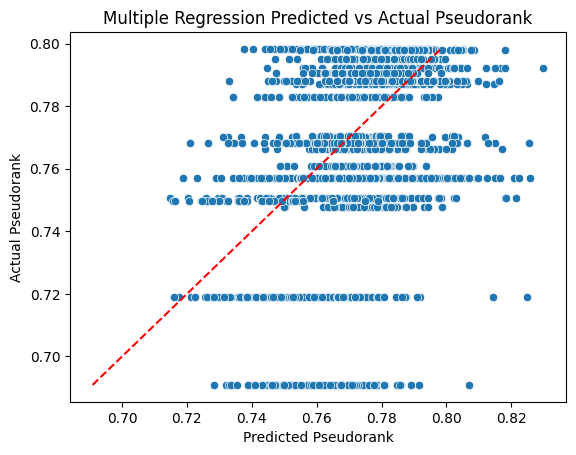

In [187]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LR, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Multiple Regression Predicted vs Actual Pseudorank')
plt.show()

In [188]:
#Run default SVM regression on dataset
SR = LinearSVR()
SR.fit(X_train_hvg, y_train_hvg)
SR.score(X_train_hvg, y_train_hvg)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


-0.3189560234425981

In [189]:
#Determine MAE with test data
y_pred_SR = np.array(SR.predict(X_test_hvg))
mae_SR = mean_absolute_error(y_test_hvg, y_pred_SR)
mape_SR = mean_absolute_percentage_error(y_test_hvg, y_pred_SR)
print(f'SVM Regression MAE: {mae_SR}')

SVM Regression MAE: 0.031061895031983245


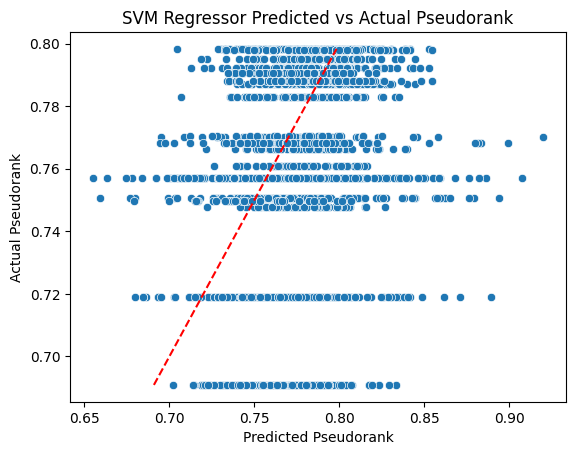

In [190]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_SR, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('SVM Regressor Predicted vs Actual Pseudorank')
plt.show()

In [191]:
#Run default Random Forest regression on dataset
RF = RandomForestRegressor()
RF.fit(X_train_hvg, y_train_hvg)
RF.score(X_train_hvg, y_train_hvg)

0.8870698086512714

In [192]:
#Determine MAE with test data
y_pred_RF = np.array(RF.predict(X_test_hvg))
mae_RF = mean_absolute_error(y_test_hvg, y_pred_RF)
mape_RF = mean_absolute_percentage_error(y_test_hvg, y_pred_RF)
print(f'Random Forest Regression MAE: {mae_RF}')

Random Forest Regression MAE: 0.022717042213183825


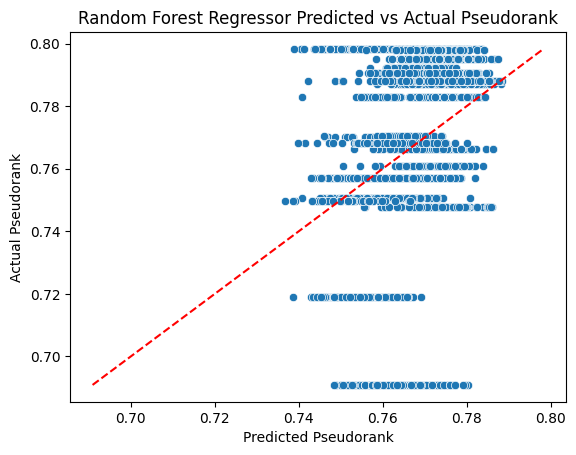

In [193]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_RF, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Random Forest Regressor Predicted vs Actual Pseudorank')
plt.show()

In [194]:
#Run default Grandient Boosting regression on dataset
GB = GradientBoostingRegressor()
GB.fit(X_train_hvg, y_train_hvg)
GB.score(X_train_hvg, y_train_hvg)

0.4722692665948963

In [195]:
#Determine MAE with test data
y_pred_GB = np.array(GB.predict(X_test_hvg))
mae_GB = mean_absolute_error(y_test_hvg, y_pred_GB)
mape_GB = mean_absolute_percentage_error(y_test_hvg, y_pred_GB)
print(f'Grandient Boosting Regression MAE: {mae_GB}')

Grandient Boosting Regression MAE: 0.021735090207413595


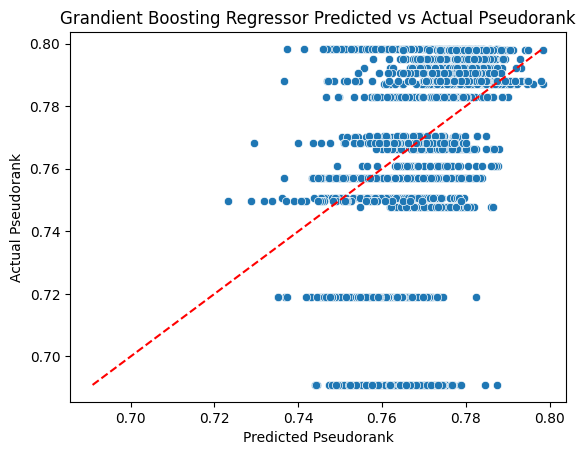

In [196]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_GB, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('Grandient Boosting Regressor Predicted vs Actual Pseudorank')
plt.show()

In [197]:
#Run default XGBoost regression on dataset
XG = XGBRegressor()
XG.fit(X_train_hvg, y_train_hvg)
XG.score(X_train_hvg, y_train_hvg)

0.9953332543373108

In [198]:
#Determine MAE with test data
y_pred_XG = np.array(XG.predict(X_test_hvg))
mae_XG = mean_absolute_error(y_test_hvg, y_pred_XG)
mape_XG = mean_absolute_percentage_error(y_test_hvg, y_pred_XG)
print(f'XGBoost Regression MAE: {mae_XG}')

XGBoost Regression MAE: 0.022595318034291267


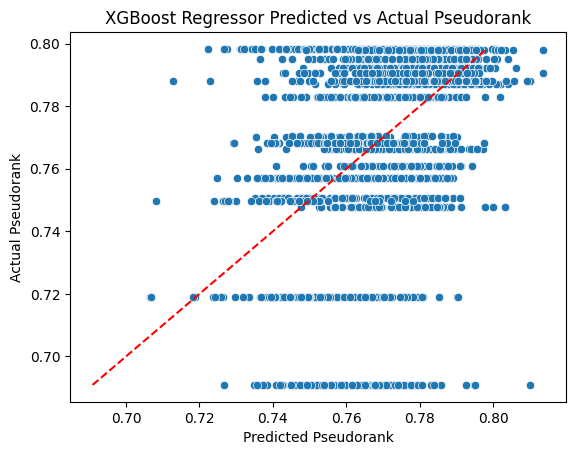

In [199]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_XG, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('XGBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [200]:
#Run default LiteGBM regression on dataset
LG = LGBMRegressor()
LG.fit(X_train_hvg, y_train_hvg)
LG.score(X_train_hvg, y_train_hvg)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016287 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 126156
[LightGBM] [Info] Number of data points in the train set: 6551, number of used features: 500
[LightGBM] [Info] Start training from score 0.767689


0.8582520572466931

In [201]:
#Determine MAE with test data
y_pred_LG = np.array(XG.predict(X_test_hvg))
mae_LG = mean_absolute_error(y_test_hvg, y_pred_LG)
mape_LG = mean_absolute_percentage_error(y_test_hvg, y_pred_LG)
print(f'LiteGBM Regressor MAE: {mae_LG}')

LiteGBM Regressor MAE: 0.022595318034291267


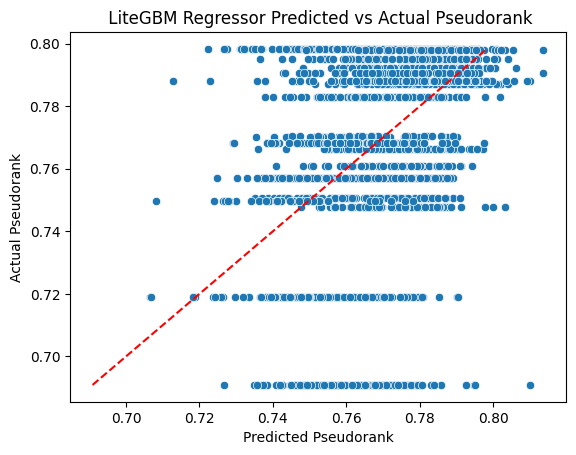

In [202]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_LG, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title(' LiteGBM Regressor Predicted vs Actual Pseudorank')
plt.show()

In [203]:
#Run default CatBoost regression on dataset
CB = CatBoostRegressor()
CB.fit(X_train_hvg, y_train_hvg)
CB.score(X_train_hvg, y_train_hvg)

Learning rate set to 0.055101
0:	learn: 0.0273751	total: 47.6ms	remaining: 47.6s
1:	learn: 0.0272265	total: 83.6ms	remaining: 41.7s
2:	learn: 0.0270837	total: 118ms	remaining: 39.2s
3:	learn: 0.0269691	total: 151ms	remaining: 37.7s
4:	learn: 0.0268662	total: 185ms	remaining: 36.8s
5:	learn: 0.0267542	total: 219ms	remaining: 36.3s
6:	learn: 0.0266374	total: 254ms	remaining: 36s
7:	learn: 0.0265334	total: 287ms	remaining: 35.6s
8:	learn: 0.0264268	total: 321ms	remaining: 35.3s
9:	learn: 0.0263232	total: 355ms	remaining: 35.1s
10:	learn: 0.0262401	total: 389ms	remaining: 35s
11:	learn: 0.0261647	total: 425ms	remaining: 35s
12:	learn: 0.0260822	total: 460ms	remaining: 34.9s
13:	learn: 0.0259905	total: 494ms	remaining: 34.8s
14:	learn: 0.0259107	total: 527ms	remaining: 34.6s
15:	learn: 0.0258402	total: 561ms	remaining: 34.5s
16:	learn: 0.0257710	total: 595ms	remaining: 34.4s
17:	learn: 0.0257099	total: 633ms	remaining: 34.5s
18:	learn: 0.0256476	total: 670ms	remaining: 34.6s
19:	learn: 0.02

np.float64(0.9240643427384986)

In [204]:
#Determine MAE with test data
y_pred_CB = np.array(CB.predict(X_test_hvg))
mae_CB = mean_absolute_error(y_test_hvg, y_pred_CB)
mape_CB = mean_absolute_percentage_error(y_test_hvg, y_pred_CB)
print(f'Grandient Boosting Regression MAE: {mae_CB}')

Grandient Boosting Regression MAE: 0.021269324321351143


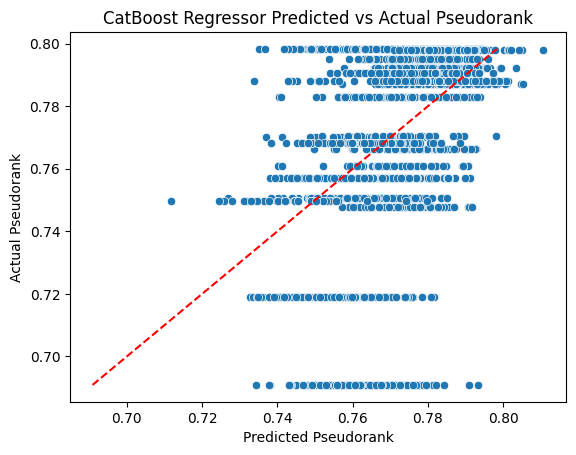

In [205]:
#Plot actual y_test vs predicted y_pred in scatterplot
sns.scatterplot(x=y_pred_CB, y=y_test_hvg)

# Add a line for perfect correlation.
plt.plot([y_test_hvg.min(), y_test_hvg.max()],
         [y_test_hvg.min(), y_test_hvg.max()],
         '--', color='red')

# Label it nicely
plt.xlabel('Predicted Pseudorank')
plt.ylabel('Actual Pseudorank')
plt.title('CatBoost Regressor Predicted vs Actual Pseudorank')
plt.show()

In [206]:
MAE_dict = {'Multiple Linear Regression': mae_LR, 'SVM Regressor': mae_SR, 'Random Forest Regressor': mae_RF,
            'Gradient Boost Regressor': mae_GB, 'XGBoost Regressor': mae_XG, 'LiteGBM Regressor': mae_LG, 'CatBoost Regressor': mae_CB}
MAPE_dict = {'Multiple Linear Regression': mape_LR, 'SVM Regressor': mape_SR, 'Random Forest Regressor': mape_RF,
            'Gradient Boost Regressor': mape_GB, 'XGBoost Regressor': mape_XG, 'LiteGBM Regressor': mape_LG, 'CatBoost Regressor': mape_CB}
Rsquared_dict = {'Multiple Linear Regression': LR.score(X_train_hvg, y_train_hvg), 'SVM Regressor': SR.score(X_train_hvg, y_train_hvg),
                 'Random Forest Regressor': RF.score(X_train_hvg, y_train_hvg), 'Gradient Boost Regressor': GB.score(X_train_hvg, y_train_hvg),
                 'XGBoost Regressor': XG.score(X_train_hvg, y_train_hvg), 'LiteGBM Regressor': LG.score(X_train_hvg, y_train_hvg), 'CatBoost Regressor': CB.score(X_train_hvg, y_train_hvg)}
summary_PR_HVG = pd.DataFrame({'MAE': MAE_dict, 'MAPE': MAPE_dict, 'R²': Rsquared_dict})
summary_PR_HVG

,MAE,MAPE,R²
Multiple Linear Regression,0.023223,0.031088,0.363211
SVM Regressor,0.031062,0.041532,-0.318956
Random Forest Regressor,0.022717,0.030332,0.887070
Gradient Boost Regressor,0.021735,0.029121,0.472269
XGBoost Regressor,0.022595,0.030234,0.995333
LiteGBM Regressor,0.022595,0.030234,0.858252
CatBoost Regressor,0.021269,0.028550,0.924064


Summary of model screening following HVG dimension rediction: The results for the HVG approach are the same as the PCA approach - all models fail to find a pattern in the data capable of predicting the DE score on a single cell level.

Since learners failed to predict the DE score, I'll now repeat the above screening with pseudorank as the target.

###Summary Model Screening

In [258]:
summary_merged = pd.concat([summary_DE_PCA.add_prefix('DE_PCA_'),
                            summary_DE_HVG.add_prefix('DE_HVG_'),
                            summary_PR_PCA.add_prefix('PR_PCA_'),
                            summary_PR_HVG.add_prefix('PR_HVG_')], axis=1)

summary_merged

,DE_PCA_MAE,DE_PCA_MAPE,DE_PCA_R²,DE_HVG_MAE,DE_HVG_MAPE,DE_HVG_R²,PR_PCA_MAE,PR_PCA_MAPE,PR_PCA_R²,PR_HVG_MAE,PR_HVG_MAPE,PR_HVG_R²
Multiple Linear Regression,0.453535,0.222941,0.342803,0.488595,0.236452,0.342840,0.022617,0.030312,0.385372,0.023223,0.031088,0.363211
SVM Regressor,0.467570,0.218851,0.207867,0.520055,0.237419,0.200720,0.030324,0.040125,-0.715854,0.031062,0.041532,-0.318956
Random Forest Regressor,0.455983,0.222411,0.930341,0.473420,0.236012,0.890629,0.021087,0.028175,0.929871,0.022717,0.030332,0.887070
Gradient Boost Regressor,0.450192,0.220855,0.560692,0.466322,0.232873,0.469062,0.022364,0.029894,0.598388,0.021735,0.029121,0.472269
XGBoost Regressor,0.468644,0.222058,0.982017,0.502500,0.243171,0.995817,0.022451,0.029931,0.983584,0.022595,0.030234,0.995333
LiteGBM Regressor,0.468644,0.222058,0.817442,0.502500,0.243171,0.827271,0.022451,0.029931,0.857552,0.022595,0.030234,0.858252
CatBoost Regressor,0.440767,0.212509,0.905408,0.459416,0.228644,0.920407,0.021973,0.029325,0.916928,0.021269,0.028550,0.924064


The above summary table has a lot of information, so I'll make a smaller tables for the MAE and MAPE to help with comparisons.

In [259]:
summary_merged_MAE = summary_merged[['DE_PCA_MAE', 'DE_HVG_MAE', 'PR_PCA_MAE', 'PR_HVG_MAE']]
summary_merged_MAE

,DE_PCA_MAE,DE_HVG_MAE,PR_PCA_MAE,PR_HVG_MAE
Multiple Linear Regression,0.453535,0.488595,0.022617,0.023223
SVM Regressor,0.467570,0.520055,0.030324,0.031062
Random Forest Regressor,0.455983,0.473420,0.021087,0.022717
Gradient Boost Regressor,0.450192,0.466322,0.022364,0.021735
XGBoost Regressor,0.468644,0.502500,0.022451,0.022595
LiteGBM Regressor,0.468644,0.502500,0.022451,0.022595
CatBoost Regressor,0.440767,0.459416,0.021973,0.021269


In [260]:
summary_merged_MAPE = summary_merged[['DE_PCA_MAPE', 'DE_HVG_MAPE', 'PR_PCA_MAPE', 'PR_HVG_MAPE']]
summary_merged_MAPE

,DE_PCA_MAPE,DE_HVG_MAPE,PR_PCA_MAPE,PR_HVG_MAPE
Multiple Linear Regression,0.222941,0.236452,0.030312,0.031088
SVM Regressor,0.218851,0.237419,0.040125,0.041532
Random Forest Regressor,0.222411,0.236012,0.028175,0.030332
Gradient Boost Regressor,0.220855,0.232873,0.029894,0.029121
XGBoost Regressor,0.222058,0.243171,0.029931,0.030234
LiteGBM Regressor,0.222058,0.243171,0.029931,0.030234
CatBoost Regressor,0.212509,0.228644,0.029325,0.028550


While these numbers don't look too bad, they are deceptively small due to the large sample size of 8000.  The scatterplots show us that the models are failing to find a pattern in the data but instead lower the MAE by predicting all cells to be in a narrow range where a majority of cells fall.  This has no practical use.

The next step will be to convert the data to pseudobulk (mimics bulk RNAseq where each donor is a single sample) and try again.  This will be done in the notebook Capstone3_iPSC_Modelling_bulk.